# 04 — Avaliação e Interpretação

**Dimensão 6 da rúbrica — 20 pontos.**

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW = Path("..") / "data" / "raw" / "dataset.csv"          # PREENCHER: nome do arquivo
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [2]:
import joblib
from pathlib import Path

# 1. Definir o caminho e carregar o dicionário
MODELS_DIR = Path("..") / "models"
modelos_carregados = joblib.load(MODELS_DIR / "modelos_credito.pkl")

# 2. Acessar individualmente cada pipeline completo
knn_model = modelos_carregados["KNN"]
svm_model = modelos_carregados["SVM"]
dt_model  = modelos_carregados["Decision_Tree"]
rf_model  = modelos_carregados["Random_Forest"]



In [3]:
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['TARGET', 'ID'])
y = df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Shape do teste:", X_test.shape)

Shape do teste: (7292, 28)


## 1. Métricas no conjunto de teste



In [5]:
#Acurácia sozinha engana em base desbalanceada.

from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay, f1_score, precision_score, recall_score
    )

In [6]:
resultados_teste = []

for nome, modelo in modelos_carregados.items():
    
    y_pred = modelo.predict(X_test)
    
    # Para o LinearSVC, predict_proba não existe. Usamos decision_function.
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = modelo.decision_function(X_test)
        
    resultados_teste.append({
        "Modelo": nome,
        "F1-Score": f1_score(y_test, y_pred) * 100,
        "Recall": recall_score(y_test, y_pred) * 100,
        "Precision": precision_score(y_test, y_pred) * 100,
        "ROC-AUC": roc_auc_score(y_test, y_proba) * 100
    })

# Criar o DataFrame e exibir
df_resultados = pd.DataFrame(resultados_teste).sort_values(by="F1-Score", ascending=False)
display(df_resultados.round(2))

,Modelo,F1-Score,Recall,Precision,ROC-AUC
3,Random_Forest,42.73,62.35,32.50,79.97
2,Decision_Tree,41.45,64.80,30.47,74.88
0,KNN,40.50,43.36,38.00,76.82
1,SVM,21.70,51.86,13.72,54.78


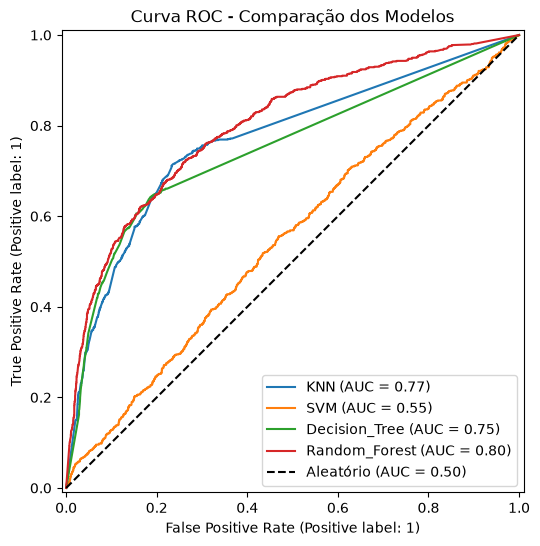

In [7]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for nome, modelo in modelos_carregados.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=nome)

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend(loc='lower right')
plt.show()

A análise da curva ROC aponta o Random Forest (em vermelho) como o modelo que melhor consegue discriminar os bons e maus pagadores. Em direção oposta, o modelo SVM (em laranja), está mais próximo à linha de base (pontilhado), reiterando que tal algoritmo não conseguiu capturar tão bem o padrão não linear dos dados.

## 2. Justificativa das métricas

_Por que estas e não acurácia pura? Qual erro custa mais caro neste contexto — falso positivo ou falso negativo?_

- A base de dados utilizada neste projeto se mostra desbalanceada, com 88% considerados como bons pagadores. Nessa situação, a métrica de acurácia dos modelos preditivos perde seu valor, sendo necessário olhar para outras alternativas, como recall e f1-score.
- Em um contexto de instituição financeira, o erro mais caro é o falso negativo - ou seja, prever como bom pagador um cliente que é mau pagador. Conceder crédito a um mau pagador implica em aumento do índice de inadimplência, elevação dos níveis de provisão e, consequentemente, impacto nos índices de capital. Um falso positivo (prever como mau pagador um cliente que é bom pagador) recai em custo de oportunidade - ou seja, perder oportunidade de angariar margem com uso de cartão. No entanto, esse cliente tem a possibilidade de ser fidelizado em outros produtos, o que, de alguma forma, equilibra tal custo.

## 3. Matriz de confusão

Matriz de confusão - Random Forest


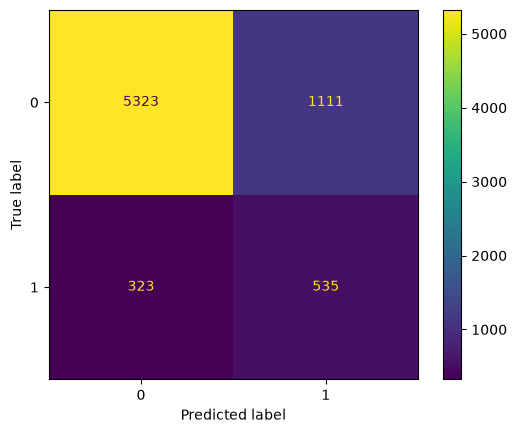

In [8]:
print("Matriz de confusão - Random Forest")
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)

plt.show()

No Random Forest, observa-se que 323 (~4%) clientes foram classficados como bom pagadores quando de fato são maus pagadores, o que significa prejuízo. Por outro lado, previu 1111 clientes (~15%) como mau pagadores quando eram bons pagadores, situação que pode representar custo de oportunidade.

Matriz de confusão - Árvore de decisão


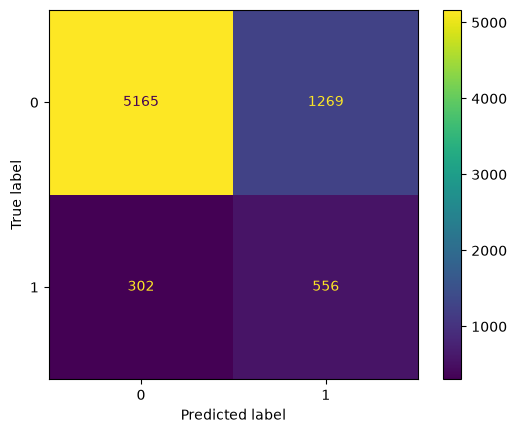

In [9]:
print("Matriz de confusão - Árvore de decisão")
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test)
plt.show()

No modelo de árvore de decisão, a matriz de confusão mostra que 302 (~4%) clientes foram classficados falsos negativos, o que significa prejuízo. Em contrapartida, previu 1269 clientes (~17%) como falsos positivos, o que significa custo de oportunidade para a instituição financeira.

Matriz de confusão - KNN


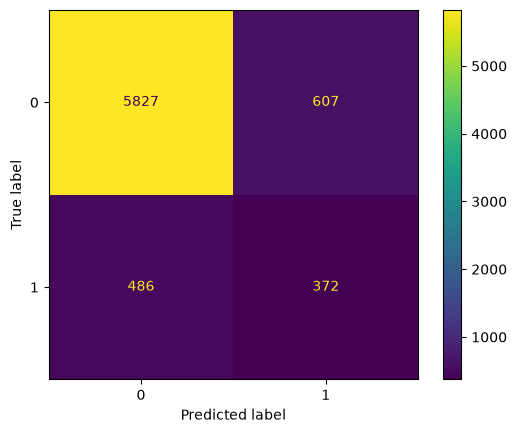

In [10]:
print("Matriz de confusão - KNN")
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test)
plt.show()

Para o modelo KNN, a matriz de confusão mostra que 486 (~7%) clientes foram classificados como bons pagadores quando são maus pagadores, indicando prejuízo. Por outro lado, previu 607 clientes (~8%) como maus pagadores quando são bons pagadores. 

Matriz de confusão - SVM


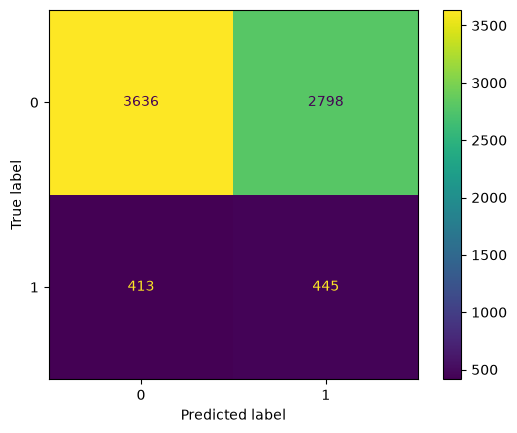

In [11]:
print("Matriz de confusão - SVM")
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)
plt.show()

Pelo modelo SVM, 413 (~6%) clientes foram classficados como falso negativo, o que significa prejuízo para a instituição. Por outro lado, previu 2798 clientes (~38%) como falso positivo, situação que pode representar custo de oportunidade.

De um modo geral, quando os modelos erram em suas previsões, sempre geram algum custo: seja prejuizo com os falsos negativos ou custo de oportunidade com os falsos positivos. Pensando em questão de inadimplência, pode ser melhor lidar com um custo de oportunidade do que com prejuízo. Nesse sentido, o Random Forest e a árvore de decisão são os modelos que trazem um melhor equilíbrio. 

## 4. Importância das variáveis

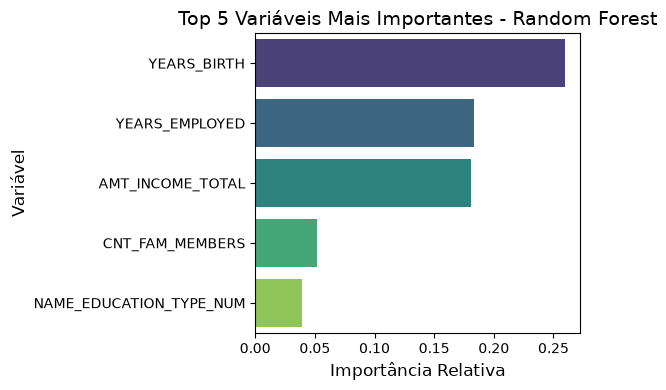

In [12]:
#**Leitura:** _quais variáveis mais pesam e isso faz sentido no domínio?_
modelo_rf = rf_model 
nome_rf = "Random Forest"

# Extração da importância das features do classificador dentro do pipeline
importancias = modelo_rf.named_steps['clf'].feature_importances_
features = X_train.columns

# DataFrame para organizar e ordenar
df_importancia = pd.DataFrame({
    'Feature': features,
    'Importancia': importancias
})

# Ordenação decrescente da variável mais importante 
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(5)

# Gráfico
plt.figure(figsize=(6, 4))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis', hue='Feature', legend=False)

plt.title(f'Top 5 Variáveis Mais Importantes - {nome_rf}', fontsize=14)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

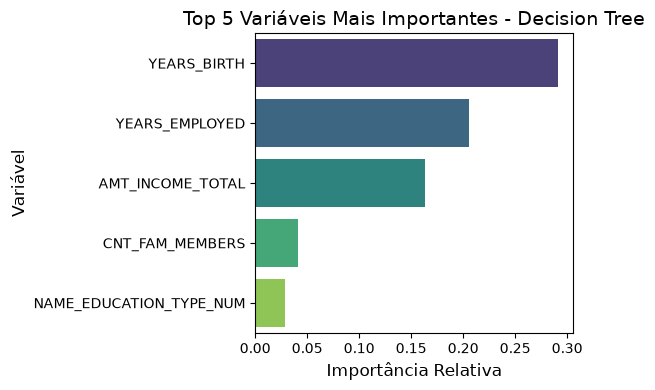

In [13]:
modelo_dt = dt_model 
nome_dt = "Decision Tree"

# Extração da importância das features do classificador dentro do pipeline
importancias = modelo_dt.named_steps['clf'].feature_importances_
features = X_train.columns

# DataFrame para organizar e ordenar
df_importancia = pd.DataFrame({
    'Feature': features,
    'Importancia': importancias
})

# Ordenação decrescente da variável mais importante 
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(5)

# Gráfico
plt.figure(figsize=(6, 4))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis', hue='Feature', legend=False)

plt.title(f'Top 5 Variáveis Mais Importantes - {nome_dt}', fontsize=14)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

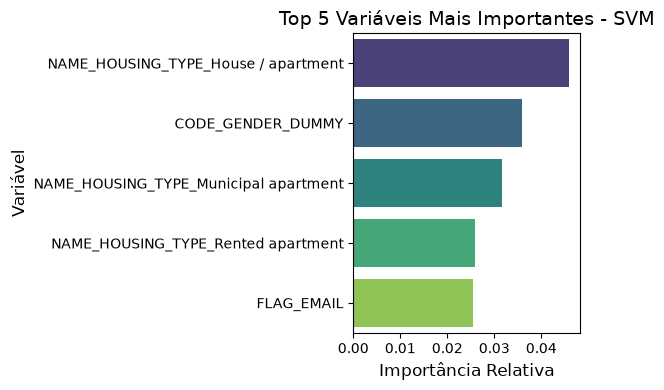

In [14]:
modelo_svm = svm_model 
nome_svm = "SVM"

# Extração da importância das features do classificador dentro do pipeline
importancias = modelo_svm.named_steps['clf'].coef_[0]
features = X_train.columns

# DataFrame para organizar e ordenar
df_importancia = pd.DataFrame({
    'Feature': features,
    'Importancia': importancias
})

# Ordenação decrescente da variável mais importante 
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(5)

# Gráfico
plt.figure(figsize=(6, 4))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis', hue='Feature', legend=False)

plt.title(f'Top 5 Variáveis Mais Importantes - {nome_svm}', fontsize=14)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

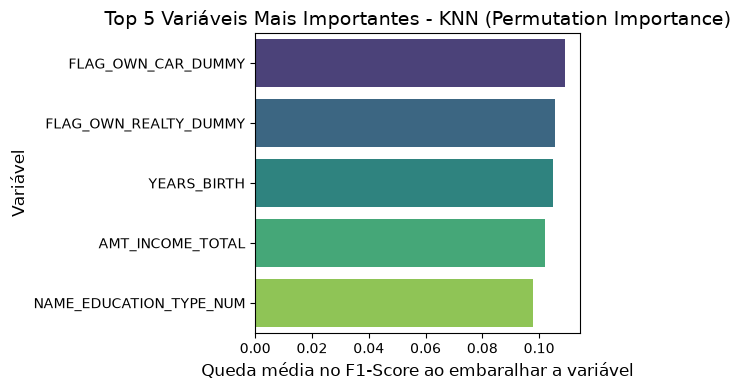

In [15]:
# Calculo da Permutation Importance no conjunto de teste

from sklearn.inspection import permutation_importance

resultado_perm = permutation_importance(
    knn_model, 
    X_test, 
    y_test, 
    n_repeats=10,          
    random_state=RANDOM_STATE, 
    scoring='f1'          
)

# Organização dos resultados em um DataFrame
df_importancia_knn = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': resultado_perm.importances_mean
})

# Ordenação de modo decrescente da variável mais importante e pegar o Top 5
df_importancia_knn = df_importancia_knn.sort_values(by='Importancia', ascending=False).head(5)

# Gráfico
plt.figure(figsize=(6, 4))
sns.barplot(x='Importancia', y='Feature', data=df_importancia_knn, palette='viridis', hue='Feature', legend=False)
plt.title('Top 5 Variáveis Mais Importantes - KNN (Permutation Importance)', fontsize=14)
plt.xlabel('Queda média no F1-Score ao embaralhar a variável', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

- Tanto no modelo Random Forest quanto no de árvore de decisão, as 5 principais variáveis são as mesmas: idade, tempo de serviço, renda e nível educacional. 
- No modelo KNN, idade, renda e nível educacional também são características importantes. 
- Já no modelo SVM, as variáveis de maior peso são diversas em comparação aos outros modelos. 
- Em um contexto de concessão de crédito, é possível dizer que idade e tempo de serviço podem ser utilizados como uma aproximação para estabilidade financeira e, consequentemente, podem representar menor nível de inadimplência. 

## 5. Implicações práticas

_O que alguém da área faria de diferente a partir destes resultados?
Escreva sem jargão — este texto é a base do vídeo executivo._

- Neste projeto, o modelo Random Forest se mostrou como boa ferramenta para análise de crédito, com Recall de 62,35% no teste - ou seja, a cada 100 clientes, ~62 são classificados corretamente como mau pagadores. 
- Contudo, observa-se também que existe um custo de oportunidade: a previsão indicou 1111 clientes (~15%) como mau pagadores quando eram bons pagadores. Visando mitigar tal custo, uma possibilidade seria levar tais clientes a um segundo nível de análise, tendo um analista de crédito fazendo uma avaliação mais criteriosa antes de negar imediatamente o crédito. 

## 6. Limitações

_Onde o modelo falha e o que você faria com mais tempo ou mais dados._

- As duas bases de dados (credit_record e application_record), a princípio, pareciam ser robustas, com uma boa quantidade de dados para treinamento e teste dos modelos. Após o cruzamento, saímos de ~400k clientes para ~36k clientes.
- A forma escolhida para definir o target pode ser otimizada - nesse projeto, marcamos como mau pagador o cliente que tivesse qualquer histórico de atraso >=30 dias, desconsiderando se em outros meses esteve adimplente. Uma possibilidade poderia ser verificar o tamanho do histórico de crédito e a partir disso, considerar uma proporção de atrasos para ser considerado mal pagador. Por exemplo: cliente com histórico de dez meses de crédito, se foi adimplente em 80% ou mais, é considerado bom pagador, mesmo que em algum momento tenha um registro de target = 5. 
- No geral, os 4 modelos aqui utilizados não se mostraram tão eficientes. Seria necessário buscar outros algoritmos mais robustos, que consigam lidar melhor com outliers, desbalanceamento e alta dimensionalidade.
- Testar outros hiperparâmetros nos modelos também poderia ser uma alternativa para sua melhoria. Contudo, requer tempo de processamento e capacidade computacional.
